# Seaborn Statistical Plots

## Overview

Seaborn provides a high-level interface to matplotlib for statistical visualisation. It integrates natively with pandas DataFrames.

**Plot families:** distributional (`histplot`, `kdeplot`, `ecdfplot`), categorical (`boxplot`, `violinplot`, `pointplot`), regression (`regplot`, `residplot`), grid (`FacetGrid`, `pairplot`).

---

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

rng = np.random.default_rng(42)
sns.set_theme(style="whitegrid", palette="muted")

n = 300
elevation = rng.uniform(50, 400, n)
sites = pd.DataFrame({
    "catchment":  rng.choice(["North", "South", "East", "West"], n),
    "elevation":  elevation.round(1),
    "nitrate":    (rng.gamma(2, 2, n) + 0.008*elevation).round(2),
    "ph":         (rng.normal(7.5, 0.3, n) - 0.002*elevation).round(2),
    "richness":   int(1),
    "treatment":  rng.choice(["control", "restored"], n),
    "year":       rng.choice([2021, 2022, 2023], n),
})
sites["richness"] = list(map(int, (20 - 0.03*elevation + rng.normal(0, 4, n)).round().clip(2,40)))
print(sites.shape)

(300, 7)


---
## Distributional Plots

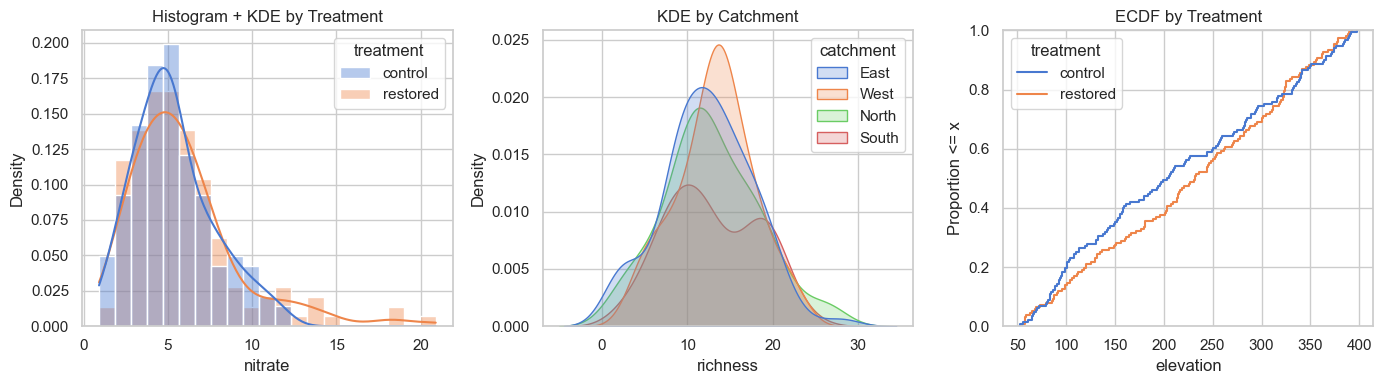

In [2]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
sns.histplot(data=sites, x="nitrate", hue="treatment", kde=True,
             stat="density", common_norm=False, alpha=0.4,
             ax=axes[0], palette="muted")
axes[0].set_title("Histogram + KDE by Treatment")
sns.kdeplot(data=sites, x="richness", hue="catchment",
            fill=True, alpha=0.25, ax=axes[1], palette="muted")
axes[1].set_title("KDE by Catchment")
sns.ecdfplot(data=sites, x="elevation", hue="treatment",
             ax=axes[2], palette="muted")
axes[2].set_title("ECDF by Treatment"); axes[2].set_ylabel("Proportion <= x")
plt.tight_layout(); plt.show()

---
## Categorical Plots

C:\Users\saman\AppData\Local\Temp\ipykernel_26036\2746045932.py:12: FutureWarning: 

The `errwidth` parameter is deprecated. And will be removed in v0.15.0. Pass `err_kws={'linewidth': 1.5}` instead.

  sns.pointplot(data=sites, x="catchment", y="richness",


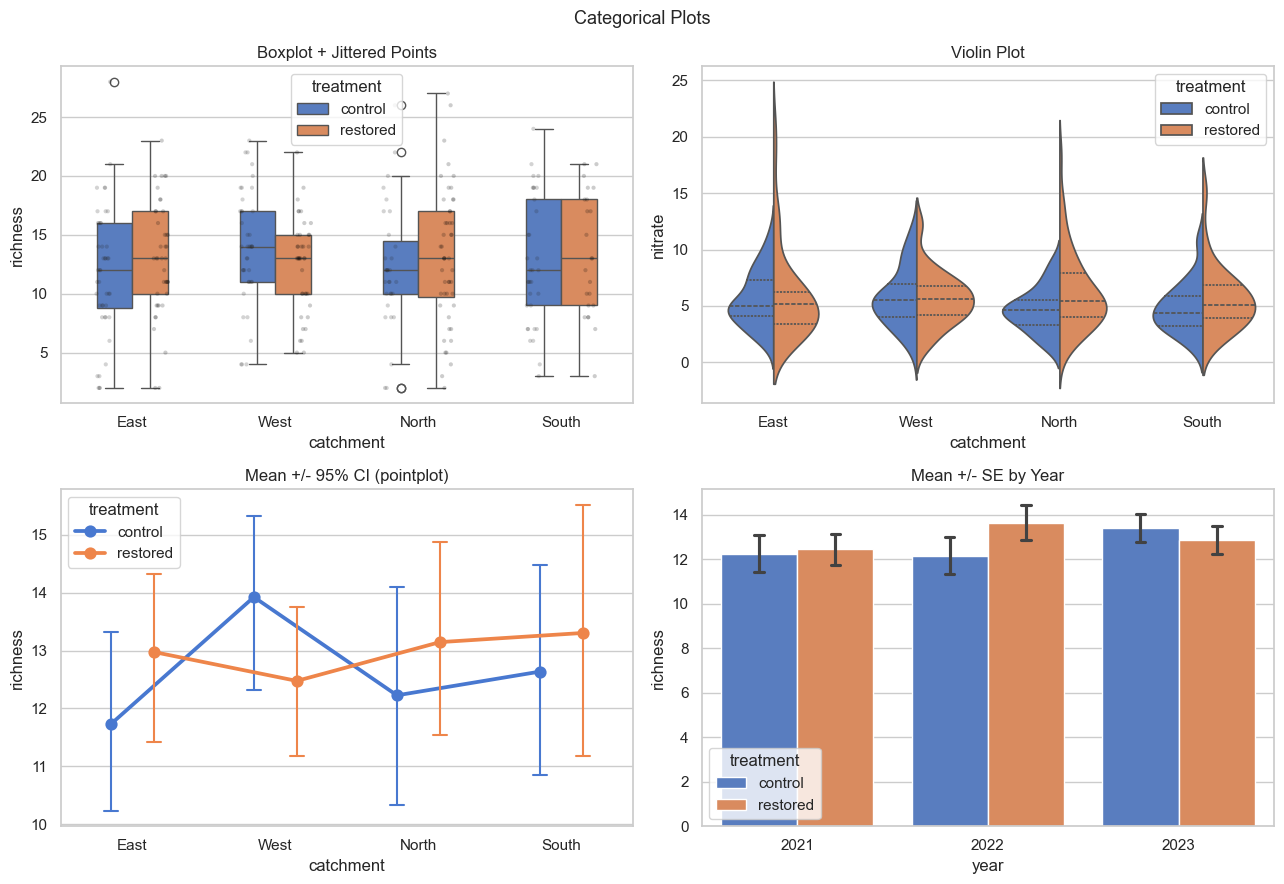

In [3]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
sns.boxplot(data=sites, x="catchment", y="richness",
            hue="treatment", ax=axes[0,0], palette="muted", width=0.5)
sns.stripplot(data=sites, x="catchment", y="richness",
              hue="treatment", ax=axes[0,0], palette="dark:black",
              alpha=0.2, size=3, dodge=True, legend=False)
axes[0,0].set_title("Boxplot + Jittered Points")
sns.violinplot(data=sites, x="catchment", y="nitrate",
               hue="treatment", split=True, inner="quart",
               ax=axes[0,1], palette="muted")
axes[0,1].set_title("Violin Plot")
sns.pointplot(data=sites, x="catchment", y="richness",
              hue="treatment", ax=axes[1,0], palette="muted",
              dodge=0.3, capsize=0.1, errwidth=1.5)
axes[1,0].set_title("Mean +/- 95% CI (pointplot)")
sns.barplot(data=sites, x="year", y="richness",
            hue="treatment", ax=axes[1,1], palette="muted",
            errorbar="se", capsize=0.1)
axes[1,1].set_title("Mean +/- SE by Year")
plt.suptitle("Categorical Plots", fontsize=13); plt.tight_layout(); plt.show()

---
## FacetGrid: Small Multiples

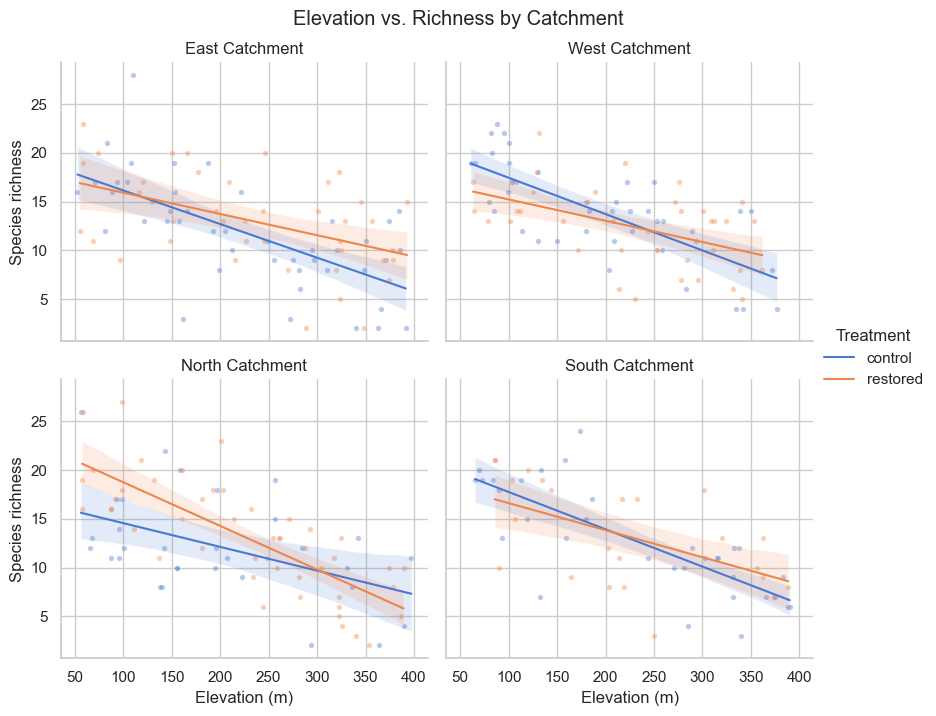

In [4]:
g = sns.FacetGrid(sites, col="catchment", hue="treatment",
                  col_wrap=2, height=3.5, aspect=1.2,
                  palette="muted", sharey=True)
g.map(sns.scatterplot, "elevation", "richness", alpha=0.4, s=15)
g.map(sns.regplot, "elevation", "richness",
      scatter=False, ci=95, line_kws={"linewidth": 1.5})
g.add_legend(title="Treatment")
g.set_axis_labels("Elevation (m)", "Species richness")
g.set_titles(col_template="{col_name} Catchment")
g.figure.suptitle("Elevation vs. Richness by Catchment", y=1.02)
plt.show()

---
## Regression and Residual Plots

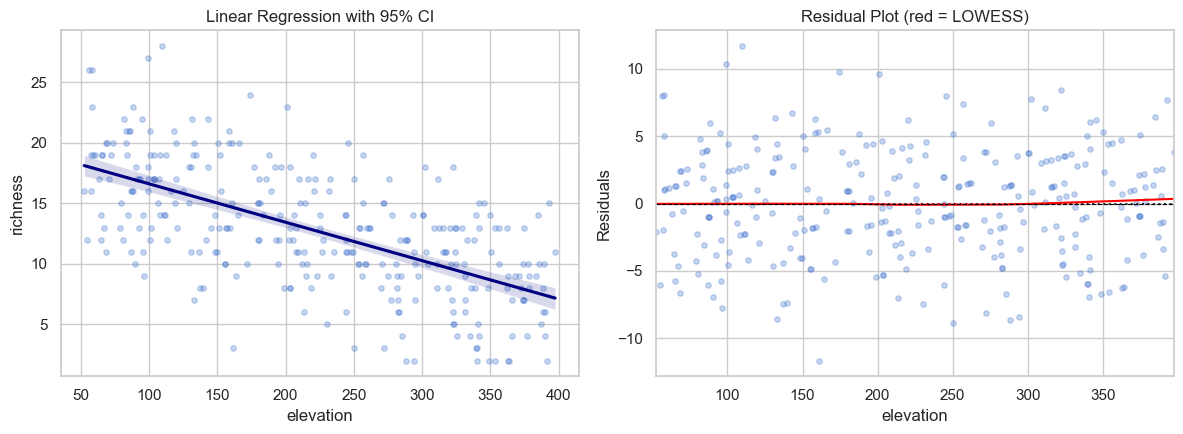

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
sns.regplot(data=sites, x="elevation", y="richness", ax=axes[0],
            scatter_kws={"alpha": 0.3, "s": 15},
            line_kws={"color": "navy"}, ci=95)
axes[0].set_title("Linear Regression with 95% CI")
sns.residplot(data=sites, x="elevation", y="richness", lowess=True, ax=axes[1],
              scatter_kws={"alpha": 0.3, "s": 15},
              line_kws={"color": "red", "linewidth": 1.5})
axes[1].axhline(0, color="black", lw=0.8, ls="--")
axes[1].set_title("Residual Plot (red = LOWESS)")
axes[1].set_ylabel("Residuals")
plt.tight_layout(); plt.show()

---

## Common Pitfalls

**1. Using the deprecated `distplot()`**  
Removed in seaborn 0.12. Use `sns.histplot(kde=True)` instead.

**2. Ignoring `common_norm` in `histplot`**  
Set `stat='density'` and `common_norm=False` to compare groups on comparable scales.

**3. Using `barplot` when `pointplot` is clearer**  
`barplot` forces y-axis to zero, exaggerating differences. `pointplot` focuses on the relevant range.

**4. Calling `lmplot` instead of `regplot` in existing figures**  
`lmplot` creates its own `FacetGrid`. Use `regplot` when you need layout control.

**5. Not setting `sharey=True` in FacetGrid**  
Per-panel auto-scaling makes cross-panel comparison misleading.
---
*python_methods_library · Samantha McGarrigle · [github.com/samantha-mcgarrigle](https://github.com/samantha-mcgarrigle)*